In [1]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
import sys
import os
import torch
from google.colab import drive
from tqdm import tqdm
from transformers import AutoTokenizer

# Monta Drive e aggiungi src al path
drive.mount('/content/drive')
BASE_DRIVE = '/content/drive/MyDrive/DeepLearning'
SRC_DIR = os.path.join(BASE_DRIVE, 'src')
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

from dataset import CLEVRDataset
from models import MultimodalCoT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Setup completato. Device: {device}")

Mounted at /content/drive


✅ Setup completato. Device: cuda


In [4]:
from torchvision import transforms

# Usa lo stesso tokenizer del training
MODEL_NAME = "t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# TRASFORMAZIONE IDENTICA AL TRAINING
transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("✅ Tokenizer e Transform pronti.")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

✅ Tokenizer e Transform pronti.


In [5]:
from torch.utils.data import DataLoader

VAL_INDEX = os.path.join(BASE_DRIVE, 'indexes/val_index.json')
VAL_IMG_DIR = os.path.join(BASE_DRIVE, 'data/processed/images/val')

val_dataset = CLEVRDataset(
    index_path=VAL_INDEX,
    img_dir=VAL_IMG_DIR,
    tokenizer=tokenizer,
    transform=transform
)

# Riutilizziamo la logica del collator per coerenza
def custom_collate_fn(batch):
    return {
        'pixel_values': torch.stack([item['pixel_values'] for item in batch]),
        'input_text': [item['input_text'] for item in batch],
        'target_text': [item['target_text'] for item in batch],
        'raw_item': [item['raw_item'] for item in batch]
    }

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate_fn)
print(f"✅ DataLoader pronto. Campioni di validazione: {len(val_dataset)}")

✅ DataLoader pronto. Campioni di validazione: 1000


In [6]:
from peft import PeftModel

ADAPTER_DIR = os.path.join(BASE_DRIVE, 'lora_adapter_final')

# 1. Inizializza l'architettura base (pesi casuali sui moduli custom)
model = MultimodalCoT().to(device)

# 2. Carica l'adapter LoRA (Il cervello linguistico)
model.llm = PeftModel.from_pretrained(model.llm, ADAPTER_DIR)

# 3. CARICA I MODULI CUSTOM (Il ponte visivo)
custom_weights_path = os.path.join(ADAPTER_DIR, 'custom_modules.pth')
if os.path.exists(custom_weights_path):
    custom_weights = torch.load(custom_weights_path, map_location=device)
    model.projector.load_state_dict(custom_weights['projector'])
    model.cross_attention.load_state_dict(custom_weights['cross_attention'])
    model.layer_norm.load_state_dict(custom_weights['layer_norm'])
    print("✅ Pesi visivi e di Cross-Attention caricati correttamente!")
else:
    print("⚠️ ATTENZIONE: File custom_modules.pth non trovato!")

# 4. Congeliamo per l'inferenza
model.eval()
print("✅ Modello caricato e pronto per la validazione.")

model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Pesi visivi e di Cross-Attention caricati correttamente!
✅ Modello caricato e pronto per la validazione.


In [9]:
import importlib
import models
importlib.reload(models) # Forza il ricaricamento delle modifiche al file

print("🔍 Analisi del ragionamento (CoT) su 5 campioni:\n")
model.eval()

with torch.no_grad():
    batch = next(iter(val_loader))
    pixel_values = batch['pixel_values'].to(device)
    inputs = tokenizer(batch['input_text'], return_tensors="pt", padding=True, truncation=True).to(device)

    # 💥 LA MODIFICA È QUI: Chiamiamo model.generate invece di model.llm.generate
    # In questo modo passiamo anche i pixel_values!
    generated_ids = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        pixel_values=pixel_values, # Ora il modello VEDE l'immagine!
        max_new_tokens=150 # Diamo abbondante spazio per il ragionamento
    )[0]

    preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    targets = batch['target_text']

    for i in range(5):
        print(f"--- ESEMPIO {i+1} ---")
        print(f"DOMANDA: {batch['input_text'][i]}")
        print(f"OUTPUT MODELLO: {preds[i]}")
        print(f"VERITÀ: {targets[i]}")
        print("-" * 30)

🔍 Analisi del ragionamento (CoT) su 5 campioni:

--- ESEMPIO 1 ---
DOMANDA: Question: What is the color of the big matte thing that is left of the big cylinder to the right of the large rubber thing to the left of the brown thing? Answer:
OUTPUT MODELLO: Let's think step by step. Look at the scene. Focus on the brown objects. Isolate the specific object. Look at what is left the previous object. Consider the large ones. Identify the rubber objects. Isolate the specific object. Look at what is right the previous object. Consider the large ones. Select the cylinders. Isolate the specific object. Look at what is left the previous object. Consider the large ones. Identify the rubber objects. Isolate the specific object. Identify its color. The final answer is: green
VERITÀ: Let's think step by step. Look at the scene. Focus on the brown objects. Isolate the specific object. Look at what is left the previous object. Consider the large ones. Identify the rubber objects. Isolate the specific 

🔍 Generazione Attention Maps Pulite (Senza Sinks)...
🎯 Estrazione mappa di attenzione isolata per la parola: 'brown' (Token: ▁brown)


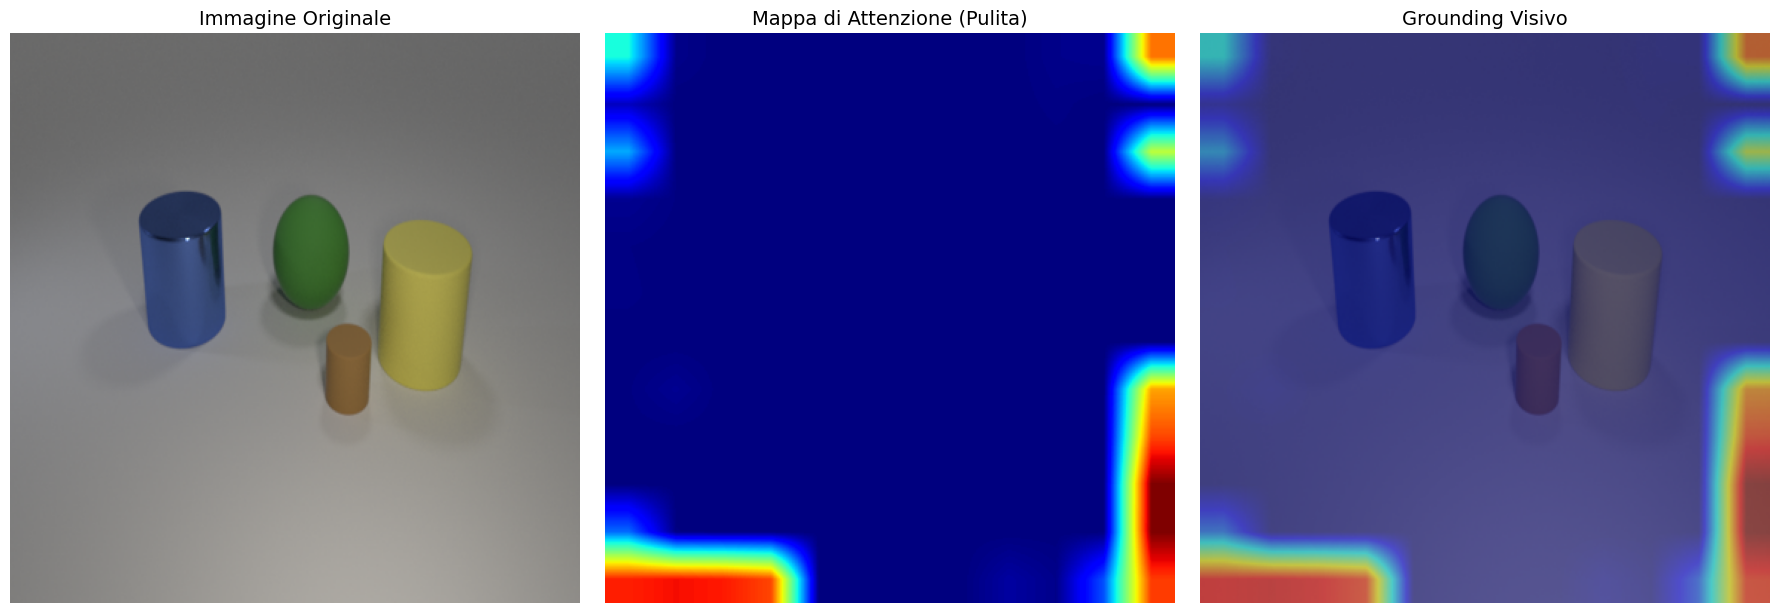


DOMANDA:
Question: What is the color of the big matte thing that is left of the big cylinder to the right of the large rubber thing to the left of the brown thing? Answer:

RAGIONAMENTO ESTRATTO DAL MODELLO:
Let's think step by step. Look at the scene. Focus on the brown objects. Isolate the specific object. Look at what is left the previous object. Consider the large ones. Identify the rubber objects. Isolate the specific object. Look at what is right the previous object. Consider the large ones. Select the cylinders. Isolate the specific object. Look at what is left the previous object. Consider the large ones. Identify the rubber objects. Isolate the specific object. Identify its color. The final answer is: green

TARGET CORRETTO:
Let's think step by step. Look at the scene. Focus on the brown objects. Isolate the specific object. Look at what is left the previous object. Consider the large ones. Identify the rubber objects. Isolate the specific object. Look at what is right the pr

In [13]:
import importlib
import models
importlib.reload(models)
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
from PIL import Image

print("🔍 Generazione Attention Maps Pulite (Senza Sinks)...")
model.eval()

with torch.no_grad():
    # Prendiamo un singolo batch
    batch = next(iter(val_loader))
    pixel_values = batch['pixel_values'].to(device)
    inputs = tokenizer(batch['input_text'], return_tensors="pt", padding=True, truncation=True).to(device)

    # Passiamo un tensore di zeri (immagine completamente nera) al posto della vera immagine
    #pixel_values = torch.zeros_like(batch['pixel_values']).to(device)

    # 1. Inferenza
    generated_ids, attn_weights = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        pixel_values=pixel_values,
        max_new_tokens=150
    )

    pred_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


    # 2. Elaborazione Mirata dell'Attention Map (Token Filtering)
    question_text = batch['input_text'][0]
    tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])

    # Scegliamo una parola chiave presente nella domanda (es. un colore o un oggetto)
    target_word = "brown" # <--- CAMBIA QUESTA PAROLA A PIACIMENTO
    target_idx = -1

    # Cerchiamo a quale indice corrisponde la nostra parola bersaglio
    for idx, token in enumerate(tokens):
        if target_word in token.lower():
            target_idx = idx
            break

    if target_idx != -1:
        print(f"🎯 Estrazione mappa di attenzione isolata per la parola: '{target_word}' (Token: {tokens[target_idx]})")
        # Prendiamo SOLO la riga di attenzione di quella specifica parola. NESSUNA MEDIA!
        patch_attn = attn_weights[0][target_idx].cpu().numpy()
    else:
        print(f"⚠️ Parola '{target_word}' non trovata. Uso la media globale.")
        patch_attn = attn_weights[0].mean(dim=0).cpu().numpy()

    # Rimuoviamo il token CLS iniziale
    if len(patch_attn) == 145:
        patch_attn = patch_attn[1:]

    # Rimodelliamo e normalizziamo
    grid_size = int(np.sqrt(len(patch_attn)))
    patch_attn = patch_attn.reshape(grid_size, grid_size)
    patch_attn = (patch_attn - patch_attn.min()) / (patch_attn.max() - patch_attn.min() + 1e-8)


    # Ridimensioniamo a 384x384
    heatmap = cv2.resize(patch_attn, (384, 384))

    # 3. Recupero immagine originale
    raw_item = batch['raw_item'][0]
    img_path = os.path.join(BASE_DRIVE, 'data/processed/images/val', raw_item['image_filename'])
    original_img = Image.open(img_path).convert('RGB').resize((384, 384))
    original_img_np = np.array(original_img)

    # Heatmap colorata
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Sovrapposizione
    superimposed_img = heatmap_colored * 0.5 + original_img_np * 0.5
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # 4. PLOTTING
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(original_img)
    axes[0].set_title("Immagine Originale", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Mappa di Attenzione (Pulita)", fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title("Grounding Visivo", fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)
    print(f"DOMANDA:\n{batch['input_text'][0]}")
    print(f"\nRAGIONAMENTO ESTRATTO DAL MODELLO:\n{pred_text}")
    print(f"\nTARGET CORRETTO:\n{batch['target_text'][0]}")
    print("="*50)

In [14]:
correct = 0
total = 0

print("🔍 Avvio inferenza sui dati di validazione...")

with torch.no_grad():
    for batch in tqdm(val_loader):
        pixel_values = batch['pixel_values'].to(device)
        inputs = tokenizer(batch['input_text'], return_tensors="pt", padding=True, truncation=True).to(device)

        # Generazione della risposta
        generated_ids = model.llm.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=100 # Lunghezza massima della risposta programmata
        )

        preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        targets = batch['target_text']

        # Confronto
        for pred, target in zip(preds, targets):
            if pred.strip() == target.strip():
                correct += 1
            total += 1

accuracy = correct / total
print(f"\n🎯 Accuracy Finale sul Validation Set: {accuracy*100:.2f}%")

🔍 Avvio inferenza sui dati di validazione...


100%|██████████| 125/125 [10:52<00:00,  5.22s/it]


🎯 Accuracy Finale sul Validation Set: 0.00%
